In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFECV
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRFRegressor
from sklearn.model_selection import GridSearchCV

In [2]:
#done
median_prices = pd.read_csv('3. Median price paid for residential properties by LSOA.csv')

In [3]:
#done
population = pd.read_csv('4. LSOA-POPULATION.csv')

In [4]:
population.rename({'Total':'Total population'},axis=1,inplace=True)

In [5]:
#done
eimd = pd.read_csv('1. 2019_Domains_of_Deprivation-EIMD.csv')

In [6]:
#done
electric = pd.read_csv('5. LSOA_electricity.csv')

In [7]:
electric.rename({'Total \nconsumption\n(kWh)':'Electricity'},axis=1,inplace=True)

In [8]:
#done
gas = pd.read_csv('6. LSOA_domestic_gas.csv')

In [9]:
gas.rename({'Total \nconsumption\n(kWh)':'Gas'},axis=1,inplace=True)

In [10]:
#done
value_added = pd.read_csv('8. GROSS VALUE ADDED.csv')

In [11]:
#done
no_of_properties = pd.read_csv('9. NUMBER OF PROPERTIES-2021.csv') 

In [12]:
no_of_properties = no_of_properties[no_of_properties['geography']=='LSOA'].copy()

In [13]:
#done
property_sales = pd.read_csv('10. Number of residential property sales by LSOA.csv')

In [14]:
#done
wimd = pd.read_excel("2. WIMD2019.xlsx",sheet_name=0)
wimd.rename(str.strip,axis=1,inplace=True)

In [15]:
columns_for_quintiles = wimd.iloc[:,4:].columns

In [16]:
for col in columns_for_quintiles:
    wimd[col] = wimd[col].apply(lambda x: 1 if x>=1 and x<=191 else 2 
                                   if x>191 and x<=382 else 3
                                   if x>382 and x<=573 else 4
                                   if x>573 and x<=764 else 5
                                   if x>764 and x<=955 else 6
                                   if x>955 and x<=1146 else 7
                                   if x>1146 and x<=1337 else 8
                                   if x>1337 and x<=1528 else 9
                                   if x>1528 and x<=1719 else 10)

In [17]:
wimd.drop(['WIMD 2019','Access to Services','Housing','Local Authority name (Eng)'],axis=1,inplace=True)

##### combine eimd and wimd

In [18]:
eimd.drop(['Barriers to Housing and Services Rank',
           'Local Authority District code (2019)', 
          'Local Authority District name (2019)'],axis=1,inplace=True)

In [19]:
eimd.rename({'Income Rank':'Income',
             'Employment Rank':'Employment', 
             'Education, Skills and Training Rank':'Education',
            'Health Deprivation and Disability Rank':'Health', 
            'Crime Rank':'Community Safety', 
             'Living Environment Rank':'Physical Environment', 
            'LSOA name (2011)':'LSOA name (Eng)',
            'LSOA code (2011)':'LSOA code'},axis=1,inplace=True)

In [20]:
eimd.rename(str.strip,axis=1,inplace=True)

In [21]:
wimd = wimd[['LSOA code','LSOA name (Eng)',
      'Income','Employment','Education',
      'Health','Community Safety','Physical Environment']].copy()

In [22]:
wimd

,LSOA code,LSOA name (Eng),Income,Employment,Education,Health,Community Safety,Physical Environment
0,W01000001,Aberffraw & Rhosneigr 1,5,4,6,7,5,10
1,W01000002,Aberffraw & Rhosneigr 2,6,7,9,7,9,10
2,W01000003,Amlwch Port,3,3,4,4,4,10
3,W01000004,Amlwch Rural,6,6,5,7,7,10
4,W01000005,Beaumaris,5,7,2,8,5,8
...,...,...,...,...,...,...,...,...
1904,W01001954,Radyr & Morganstown 4,10,8,10,10,10,5
1905,W01001955,Castle 2 North,1,1,3,1,1,3
1906,W01001956,Killay 3,10,10,10,9,10,8
1907,W01001957,Castle 7 West,3,5,5,3,1,2


In [23]:
eimd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32844 entries, 0 to 32843
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   LSOA code             32844 non-null  object
 1   LSOA name (Eng)       32844 non-null  object
 2   Income                32844 non-null  int64 
 3   Employment            32844 non-null  int64 
 4   Education             32844 non-null  int64 
 5   Health                32844 non-null  int64 
 6   Community Safety      32844 non-null  int64 
 7   Physical Environment  32844 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 2.0+ MB


In [24]:
imd = pd.concat([wimd,eimd]).copy()

#### combine imd with median price

In [25]:
march = median_prices['Median price paid for residential properties Year ending Mar 2021']==":"

In [26]:
median_prices_updated_1 = median_prices[~march].copy()

In [27]:
june = median_prices_updated_1['Median price paid for residential properties Year ending Jun 2021']==":"

In [28]:
median_prices_updated_2 = median_prices_updated_1[~june]

In [29]:
sept = median_prices_updated_2['Median price paid for residential properties Year ending Sep 2021']==":"

In [30]:
median_prices_updated_3 = median_prices_updated_2[~sept]

In [31]:
dec = median_prices_updated_3['Median price paid for residential properties Year ending Dec 2021']==":"

In [32]:
median_prices_updated_4 = median_prices_updated_3[~dec]

In [33]:
median_prices_updated_4['Median price paid for residential properties Year ending Dec 2021'] = median_prices_updated_4['Median price paid for residential properties Year ending Dec 2021'].astype('float')

C:\Users\30111702\AppData\Local\Temp\ipykernel_10884\3559322396.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  median_prices_updated_4['Median price paid for residential properties Year ending Dec 2021'] = median_prices_updated_4['Median price paid for residential properties Year ending Dec 2021'].astype('float')


In [34]:
median_prices_updated_4['Median price paid for residential properties Year ending Jun 2021'] = median_prices_updated_4['Median price paid for residential properties Year ending Jun 2021'].astype('float')

C:\Users\30111702\AppData\Local\Temp\ipykernel_10884\900771510.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  median_prices_updated_4['Median price paid for residential properties Year ending Jun 2021'] = median_prices_updated_4['Median price paid for residential properties Year ending Jun 2021'].astype('float')


In [35]:
median_prices_updated_4['Median price paid for residential properties Year ending Mar 2021'] = median_prices_updated_4['Median price paid for residential properties Year ending Mar 2021'].astype('float')

C:\Users\30111702\AppData\Local\Temp\ipykernel_10884\3534788220.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  median_prices_updated_4['Median price paid for residential properties Year ending Mar 2021'] = median_prices_updated_4['Median price paid for residential properties Year ending Mar 2021'].astype('float')


In [36]:
median_prices_updated_4['Median price paid for residential properties Year ending Sep 2021'] = median_prices_updated_4['Median price paid for residential properties Year ending Sep 2021'].astype('float')

C:\Users\30111702\AppData\Local\Temp\ipykernel_10884\681533920.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  median_prices_updated_4['Median price paid for residential properties Year ending Sep 2021'] = median_prices_updated_4['Median price paid for residential properties Year ending Sep 2021'].astype('float')


In [37]:
median_prices_updated_4

,Local authority code,Local authority name,LSOA code,LSOA name,Median price paid for residential properties Year ending Mar 2021,Median price paid for residential properties Year ending Jun 2021,Median price paid for residential properties Year ending Sep 2021,Median price paid for residential properties Year ending Dec 2021
0,E06000001,Hartlepool,E01011949,Hartlepool 009A,81500.0,80500.0,89000.0,101500.0
1,E06000001,Hartlepool,E01011950,Hartlepool 008A,33000.0,47000.0,49999.0,50159.0
2,E06000001,Hartlepool,E01011951,Hartlepool 007A,51500.0,53000.0,58573.5,60000.0
5,E06000001,Hartlepool,E01011954,Hartlepool 001A,159950.0,151750.0,98499.5,115500.0
6,E06000001,Hartlepool,E01011955,Hartlepool 003A,75000.0,72500.0,60749.5,69000.0
...,...,...,...,...,...,...,...,...
34747,W06000024,Merthyr Tydfil,W01001319,Merthyr Tydfil 007B,235000.0,230000.0,225000.0,215000.0
34748,W06000024,Merthyr Tydfil,W01001320,Merthyr Tydfil 007C,144000.0,141500.0,140000.0,140000.0
34749,W06000024,Merthyr Tydfil,W01001321,Merthyr Tydfil 007D,100750.0,107000.0,110000.0,109500.0
34750,W06000024,Merthyr Tydfil,W01001322,Merthyr Tydfil 007E,100000.0,105000.0,105000.0,107500.0


In [38]:
imd

,LSOA code,LSOA name (Eng),Income,Employment,Education,Health,Community Safety,Physical Environment
0,W01000001,Aberffraw & Rhosneigr 1,5,4,6,7,5,10
1,W01000002,Aberffraw & Rhosneigr 2,6,7,9,7,9,10
2,W01000003,Amlwch Port,3,3,4,4,4,10
3,W01000004,Amlwch Rural,6,6,5,7,7,10
4,W01000005,Beaumaris,5,7,2,8,5,8
...,...,...,...,...,...,...,...,...
32839,E01033764,Liverpool 022E,1,1,1,1,1,5
32840,E01033765,Liverpool 061D,1,1,1,1,2,7
32841,E01033766,Liverpool 042G,6,6,7,2,5,1
32842,E01033767,Liverpool 050J,1,1,1,1,4,1


In [39]:
#based on imd

imd_median_prices = imd.merge(median_prices_updated_4, left_on=['LSOA code','LSOA name (Eng)'],right_on=['LSOA code','LSOA name']).copy()

In [40]:
imd_median_prices

,LSOA code,LSOA name (Eng),Income,Employment,Education,Health,Community Safety,Physical Environment,Local authority code,Local authority name,LSOA name,Median price paid for residential properties Year ending Mar 2021,Median price paid for residential properties Year ending Jun 2021,Median price paid for residential properties Year ending Sep 2021,Median price paid for residential properties Year ending Dec 2021
0,E01000001,City of London 001A,10,10,10,10,10,3,E09000001,City of London,City of London 001A,800000.0,817500.0,820000.0,840000.0
1,E01000002,City of London 001B,10,10,10,10,10,4,E09000001,City of London,City of London 001B,808500.0,807500.0,822500.0,817500.0
2,E01000003,City of London 001C,6,5,9,6,9,2,E09000001,City of London,City of London 001C,639500.0,574250.0,545000.0,540000.0
3,E01000006,Barking and Dagenham 016A,5,7,6,7,6,4,E09000002,Barking and Dagenham,Barking and Dagenham 016A,412500.0,400000.0,410000.0,410000.0
4,E01000007,Barking and Dagenham 015A,2,4,7,5,2,4,E09000002,Barking and Dagenham,Barking and Dagenham 015A,325000.0,330000.0,330000.0,330000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31685,E01033763,Liverpool 031G,1,1,1,1,1,3,E08000012,Liverpool,Liverpool 031G,170500.0,210995.0,211995.0,213495.0
31686,E01033764,Liverpool 022E,1,1,1,1,1,5,E08000012,Liverpool,Liverpool 022E,134000.0,123500.0,147000.0,160000.0
31687,E01033765,Liverpool 061D,1,1,1,1,2,7,E08000012,Liverpool,Liverpool 061D,164975.0,190000.0,190000.0,205000.0
31688,E01033766,Liverpool 042G,6,6,7,2,5,1,E08000012,Liverpool,Liverpool 042G,213250.0,215000.0,230000.0,230000.0


##### electric and gas


In [41]:
energy = electric.merge(gas,on=['LSOA code','Lower layer super output area']).copy()

In [42]:
energy

,LSOA code,Lower layer super output area,Electricity,Gas
0,E01011954,Hartlepool 001A,2.766141e+06,1.100646e+07
1,E01011969,Hartlepool 001B,1.788105e+06,8.216660e+06
2,E01011970,Hartlepool 001C,1.429580e+06,5.961545e+06
3,E01011971,Hartlepool 001D,1.787027e+06,6.860002e+06
4,E01033465,Hartlepool 001F,2.730189e+06,1.145318e+07
...,...,...,...,...
42644,W01001301,Merthyr Tydfil 008C,2.374230e+06,1.054002e+07
42645,W01001308,Merthyr Tydfil 008D,1.758205e+06,7.032447e+06
42646,W01001309,Merthyr Tydfil 008E,1.724639e+06,7.480842e+06
42647,W01001898,Merthyr Tydfil 008F,2.357512e+06,5.927526e+06


In [43]:
imd_median_energy = imd_median_prices.merge(energy,left_on=['LSOA code','LSOA name (Eng)'], 
                        right_on=['LSOA code','Lower layer super output area']).copy()

##### population

In [44]:
imd_median_energy_pop = imd_median_energy.merge(population, left_on=['LSOA code','LSOA name (Eng)'],
                                            right_on=['LSOA 2021 Code','LSOA 2021 Name']).copy()

##### value added

In [45]:
imd_median_energy_pop_value = imd_median_energy_pop.merge(value_added, left_on=['LSOA code','LSOA name (Eng)'],
                               right_on=['LSOA code','2011 super output area - lower layer']).copy()

##### no of properties

In [46]:
imd_median_energy_pop_value_prop = imd_median_energy_pop_value.merge(no_of_properties, 
                                                                     left_on=['LSOA code','LSOA name (Eng)'],
                                                     right_on=['ecode','area_name']).copy()

In [47]:
imd_median_energy_pop_value_prop

,LSOA code,LSOA name (Eng),Income,Employment,Education,Health,Community Safety,Physical Environment,Local authority code,Local authority name,...,LAD 2021 Name,LSOA 2021 Code,LSOA 2021 Name,Total population,2021 Gross value added in pounds million,2011 super output area - lower layer,geography,ecode,area_name,all_properties
0,E01000001,City of London 001A,10,10,10,10,10,3,E09000001,City of London,...,City of London,E01000001,City of London 001A,1573,1802.146,City of London 001A,LSOA,E01000001,City of London 001A,1050
1,E01000002,City of London 001B,10,10,10,10,10,4,E09000001,City of London,...,City of London,E01000002,City of London 001B,1407,17166.146,City of London 001B,LSOA,E01000002,City of London 001B,1160
2,E01000003,City of London 001C,6,5,9,6,9,2,E09000001,City of London,...,City of London,E01000003,City of London 001C,1610,60.882,City of London 001C,LSOA,E01000003,City of London 001C,1190
3,E01000006,Barking and Dagenham 016A,5,7,6,7,6,4,E09000002,Barking and Dagenham,...,Barking and Dagenham,E01000006,Barking and Dagenham 016A,1829,5.854,Barking and Dagenham 016A,LSOA,E01000006,Barking and Dagenham 016A,530
4,E01000007,Barking and Dagenham 015A,2,4,7,5,2,4,E09000002,Barking and Dagenham,...,Barking and Dagenham,E01000007,Barking and Dagenham 015A,2841,137.560,Barking and Dagenham 015A,LSOA,E01000007,Barking and Dagenham 015A,1290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28682,E01033761,Liverpool 060D,10,10,9,3,1,1,E08000012,Liverpool,...,Liverpool,E01033761,Liverpool 060D,2095,122.263,Liverpool 060D,LSOA,E01033761,Liverpool 060D,1910
28683,E01033762,Liverpool 060E,6,9,7,1,3,5,E08000012,Liverpool,...,Liverpool,E01033762,Liverpool 060E,3566,107.382,Liverpool 060E,LSOA,E01033762,Liverpool 060E,1830
28684,E01033763,Liverpool 031G,1,1,1,1,1,3,E08000012,Liverpool,...,Liverpool,E01033763,Liverpool 031G,2517,18.335,Liverpool 031G,LSOA,E01033763,Liverpool 031G,1250
28685,E01033765,Liverpool 061D,1,1,1,1,2,7,E08000012,Liverpool,...,Liverpool,E01033765,Liverpool 061D,1499,32.504,Liverpool 061D,LSOA,E01033765,Liverpool 061D,720


##### sales

In [48]:
imd_median_energy_pop_value_prop_sales = imd_median_energy_pop_value_prop.merge(property_sales,
                                                            left_on=['LSOA code','LSOA name (Eng)'],
                                                      right_on=['LSOA code','LSOA name']).copy()

# dropping names

In [49]:
imd_median_energy_pop_value_prop_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28687 entries, 0 to 28686
Data columns (total 36 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   LSOA code                                                          28687 non-null  object 
 1   LSOA name (Eng)                                                    28687 non-null  object 
 2   Income                                                             28687 non-null  int64  
 3   Employment                                                         28687 non-null  int64  
 4   Education                                                          28687 non-null  int64  
 5   Health                                                             28687 non-null  int64  
 6   Community Safety                                                   28687 non-null  int64  
 7   Physical Environment  

In [50]:
final = imd_median_energy_pop_value_prop_sales.drop(['Local authority code_x',
                                             'Local authority name_x', 
                                             'LSOA name_x','LAD 2021 Code','LAD 2021 Name',
                                            'LSOA 2021 Code','LSOA 2021 Name',
                                            '2011 super output area - lower layer',
                                            'ecode','area_name','Local authority code_y',
                                            'Local authority name_y','LSOA name_y','geography',
                                            'Lower layer super output area'],axis=1).copy()

In [51]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28687 entries, 0 to 28686
Data columns (total 21 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   LSOA code                                                          28687 non-null  object 
 1   LSOA name (Eng)                                                    28687 non-null  object 
 2   Income                                                             28687 non-null  int64  
 3   Employment                                                         28687 non-null  int64  
 4   Education                                                          28687 non-null  int64  
 5   Health                                                             28687 non-null  int64  
 6   Community Safety                                                   28687 non-null  int64  
 7   Physical Environment  

In [52]:
#employment
#employment = pd.read_csv('census2021-economic activity-employed_1.csv')

In [53]:
#employment['Employed Persons'] = employment.iloc[:,3:].sum(axis=1)

In [54]:
#employment_updated= employment.iloc[:,[1,2,5]].copy()

In [55]:
#employment_updated.head(1)

In [56]:
#final_updated_1 = final.merge(employment_updated, left_on=['LSOA code','LSOA name (Eng)'], 
#                                right_on=['geography code','geography']).copy()

In [57]:
#final_updated_1.drop(['geography', 'geography code'],axis=1,inplace=True)

In [58]:
#population density
population_density = pd.read_csv('census2021-population density.csv')

In [59]:
population_density.drop('date',axis=1,inplace=True)

In [60]:
final_updated_2 = final.merge(population_density, left_on= ['LSOA code','LSOA name (Eng)'],
                        right_on= ['geography code','geography']).drop(['geography', 'geography code'],axis=1).copy()

In [61]:
#type of house
house_type = pd.read_csv('census2021-type of houses_1.csv')

In [62]:
final_updated_3 = final_updated_2.merge(house_type, left_on= ['LSOA code','LSOA name (Eng)'],
                        right_on= ['geography code','geography']).drop(['geography', 'geography code'],axis=1).copy()

In [63]:
final_updated_3.rename({'Part of another converted building, for example, former school, church or warehouse':'Part of another converted building',
                       'In a commercial building, for example, in an office building, hotel or over a shop':'In a commercial building',
                       'Part of a converted or shared house, including bedsits':'Part of a converted or shared house',
                       'Population Density: Persons per square kilometre; measures: Value': 'Population Density'},axis=1, inplace=True)

In [64]:
final = final_updated_3.copy()

In [65]:
#final.to_csv('housing_data.csv')

# MAIN WORK

In [66]:
print(f"Shape of the data: {final.shape}")

#the initial dataset for the analysis includes 28,687 observations and 21 features related to different LSOA.
final.head(3)

Shape of the data: (28687, 30)


,LSOA code,LSOA name (Eng),Income,Employment,Education,Health,Community Safety,Physical Environment,Median price paid for residential properties Year ending Mar 2021,Median price paid for residential properties Year ending Jun 2021,...,Number of residential property sales Year ending Dec 2021,Population Density,Detached,Semi-detached,Terraced,In a purpose-built block of flats or tenement,Part of a converted or shared house,Part of another converted building,In a commercial building,A caravan or other mobile or temporary structure
0,E01000001,City of London 001A,10,10,10,10,10,3,800000.0,817500.0,...,35,11363.6,0,3,13,803,0,11,7,0
1,E01000002,City of London 001B,10,10,10,10,10,4,808500.0,807500.0,...,40,6062.2,1,2,29,769,2,13,9,0
2,E01000003,City of London 001C,6,5,9,6,9,2,639500.0,574250.0,...,24,27385.4,1,0,0,994,2,13,7,0


# EDA

In [67]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28687 entries, 0 to 28686
Data columns (total 30 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   LSOA code                                                          28687 non-null  object 
 1   LSOA name (Eng)                                                    28687 non-null  object 
 2   Income                                                             28687 non-null  int64  
 3   Employment                                                         28687 non-null  int64  
 4   Education                                                          28687 non-null  int64  
 5   Health                                                             28687 non-null  int64  
 6   Community Safety                                                   28687 non-null  int64  
 7   Physical Environment  

In [68]:
#dependent variable is the median values of price houses recorded for each quarter of 2021
final['Median price 2021'] = final[['Median price paid for residential properties Year ending Mar 2021',
                                  'Median price paid for residential properties Year ending Jun 2021',
                                  'Median price paid for residential properties Year ending Sep 2021',
                                  'Median price paid for residential properties Year ending Dec 2021']].median(axis=1)

final.drop(['Median price paid for residential properties Year ending Mar 2021',
                          'Median price paid for residential properties Year ending Jun 2021',
                          'Median price paid for residential properties Year ending Sep 2021',
                          'Median price paid for residential properties Year ending Dec 2021'],axis=1,inplace=True)

final

,LSOA code,LSOA name (Eng),Income,Employment,Education,Health,Community Safety,Physical Environment,Electricity,Gas,...,Population Density,Detached,Semi-detached,Terraced,In a purpose-built block of flats or tenement,Part of a converted or shared house,Part of another converted building,In a commercial building,A caravan or other mobile or temporary structure,Median price 2021
0,E01000001,City of London 001A,10,10,10,10,10,3,4240045.812,5.163359e+05,...,11363.6,0,3,13,803,0,11,7,0,818750.00
1,E01000002,City of London 001B,10,10,10,10,10,4,4208466.798,4.185856e+05,...,6062.2,1,2,29,769,2,13,9,0,813000.00
2,E01000003,City of London 001C,6,5,9,6,9,2,3171257.049,4.168506e+06,...,27385.4,1,0,0,994,2,13,7,0,559625.00
3,E01000006,Barking and Dagenham 016A,5,7,6,7,6,4,2120774.473,6.383270e+06,...,12585.3,34,88,283,121,24,3,0,1,410000.00
4,E01000007,Barking and Dagenham 015A,2,4,7,5,2,4,4278538.428,3.948580e+06,...,14540.0,15,47,153,939,8,8,14,7,330000.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28682,E01033761,Liverpool 060D,10,10,9,3,1,1,6183462.995,2.028725e+06,...,17277.8,8,7,9,918,39,59,29,1,136750.00
28683,E01033762,Liverpool 060E,6,9,7,1,3,5,1888040.105,2.474082e+06,...,21965.4,3,12,9,483,4,66,24,1,78998.75
28684,E01033763,Liverpool 031G,1,1,1,1,1,3,3263707.425,9.815343e+06,...,7711.8,61,209,391,256,98,9,7,0,211495.00
28685,E01033765,Liverpool 061D,1,1,1,1,2,7,2667160.439,5.972995e+06,...,4371.0,41,287,203,184,1,0,1,4,190000.00


In [69]:
final.isna().sum()

#the number of null values present in the dataset

LSOA code                                                      0
LSOA name (Eng)                                                0
Income                                                         0
Employment                                                     0
Education                                                      0
Health                                                         0
Community Safety                                               0
Physical Environment                                           0
Electricity                                                    4
Gas                                                          717
Total population                                               0
2021 Gross value added in pounds million                       0
all_properties                                                 0
Number of residential property sales Year ending Mar 2021      0
Number of residential property sales Year ending Jun 2021      0
Number of residential pro

# SPLITTING DATA INTO TRAIN AND TEST SETS

In [70]:
#splitting data into train and test datasets
X = final.drop('Median price 2021',axis=1).copy()
y = final['Median price 2021'].values

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 4)

In [72]:
#an initial investigation necessitated the summation of the number of residential property sales for each quarter of the
#year. This is included in the histogram plot below:

def feature_creation(data):
    data['Total number of property sales 2021'] = data[['Number of residential property sales Year ending Mar 2021',
                                              'Number of residential property sales Year ending Jun 2021',
                                              'Number of residential property sales Year ending Sep 2021',
                                              'Number of residential property sales Year ending Dec 2021']].sum(axis=1)

    data.drop(['Number of residential property sales Year ending Mar 2021',
                                  'Number of residential property sales Year ending Jun 2021',
                                  'Number of residential property sales Year ending Sep 2021',
                                  'Number of residential property sales Year ending Dec 2021'],axis=1,inplace=True)
    
    #feature creation
    # the following features were created 

    data['Average energy consumption'] = data[['Electricity','Gas']].mean(axis=1)
    data['Electricity cons. per person'] = data['Electricity'] / data['Total population']
    data['Gas cons. per person'] = data['Gas'] / data['Total population']
    data['Average energy cons. per person'] = data['Average energy consumption'] / data['Total population']
    data['Gas cons. per property'] = data['Gas'] / data['all_properties']
    data['Electricity con. per property'] = data['Electricity'] / data['all_properties']
    
    
    data_updated_1 = data.drop(['LSOA code', 'LSOA name (Eng)'],axis=1).copy()
    
    return data_updated_1

In [73]:
#creating features for X_train data
X_train = feature_creation(X_train).copy()

# Using X_train for visualization

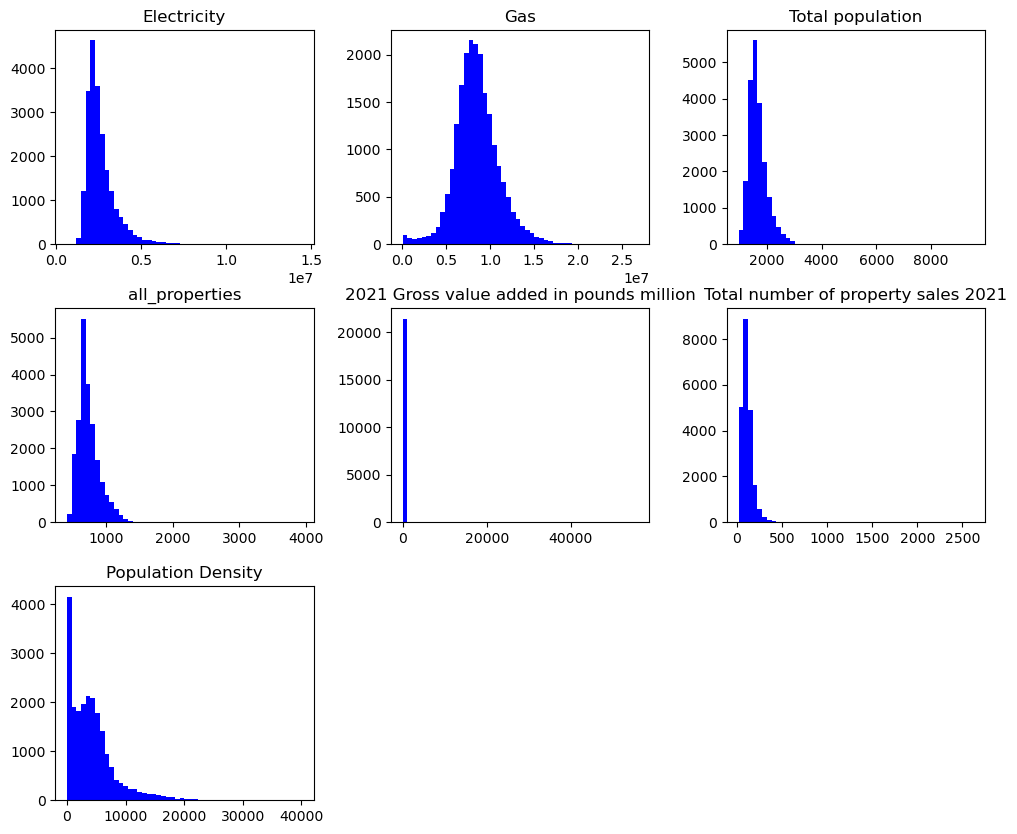

In [74]:
#distribution of some variables
X_train[['Electricity','Gas',
       'Total population',
       'all_properties',
       '2021 Gross value added in pounds million',
      'Total number of property sales 2021','Population Density']].hist(figsize=(12,10),bins=50,color='blue',grid=False)
plt.show()

#the histograms show that the variables are skewed. Further, the scale of measurement for variables are different, 
#example being GVA being in million pounds while properties and populations are counted in the thousands.

#The skweness of the data will be addressed by applying log root transformation while the different scale of 
#measurement will be treated by employing StandardScaler, a pre-processing technique in scikit-learn that 
#standardizes values in a feature.

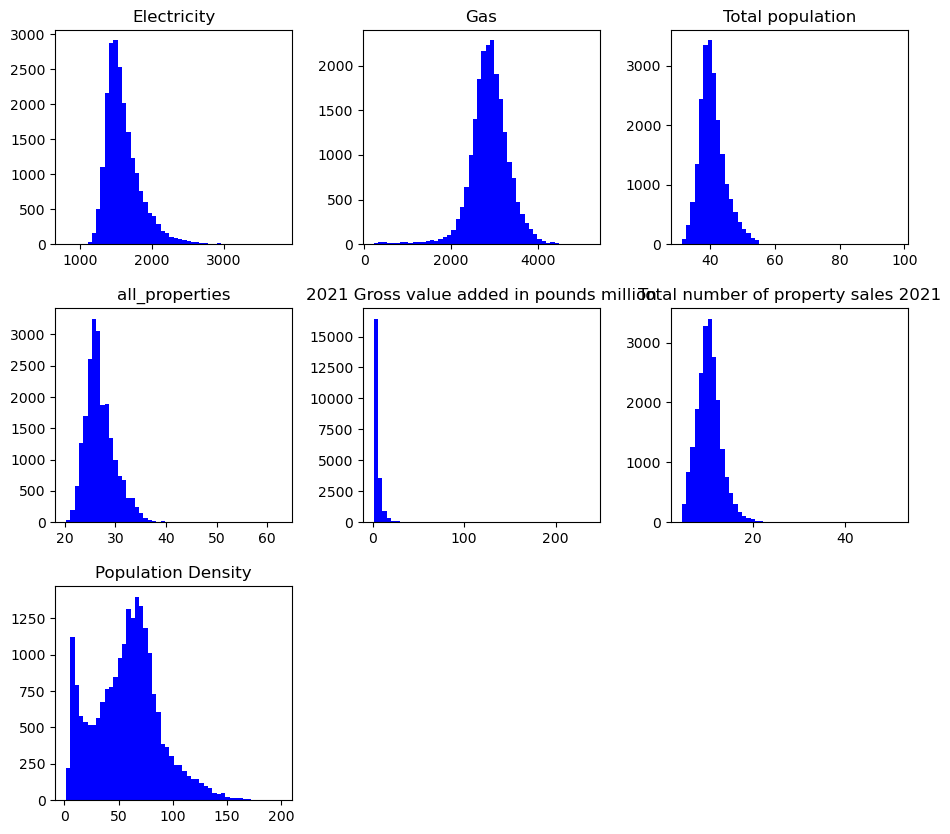

In [75]:
#this will be the result of after transforming the features using log root transformation

np.sqrt(X_train[['Electricity','Gas',
       'Total population',
       'all_properties',
       '2021 Gross value added in pounds million','Total number of property sales 2021', 
        'Population Density']]).hist(figsize=(11,10),bins=50,color='blue', grid=False)
plt.show()

In [76]:
#Correlation was performed to check the relationship between variables.

correlations = X_train.corr(numeric_only=True)
mask = np.triu(np.ones_like(correlations))

C:\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


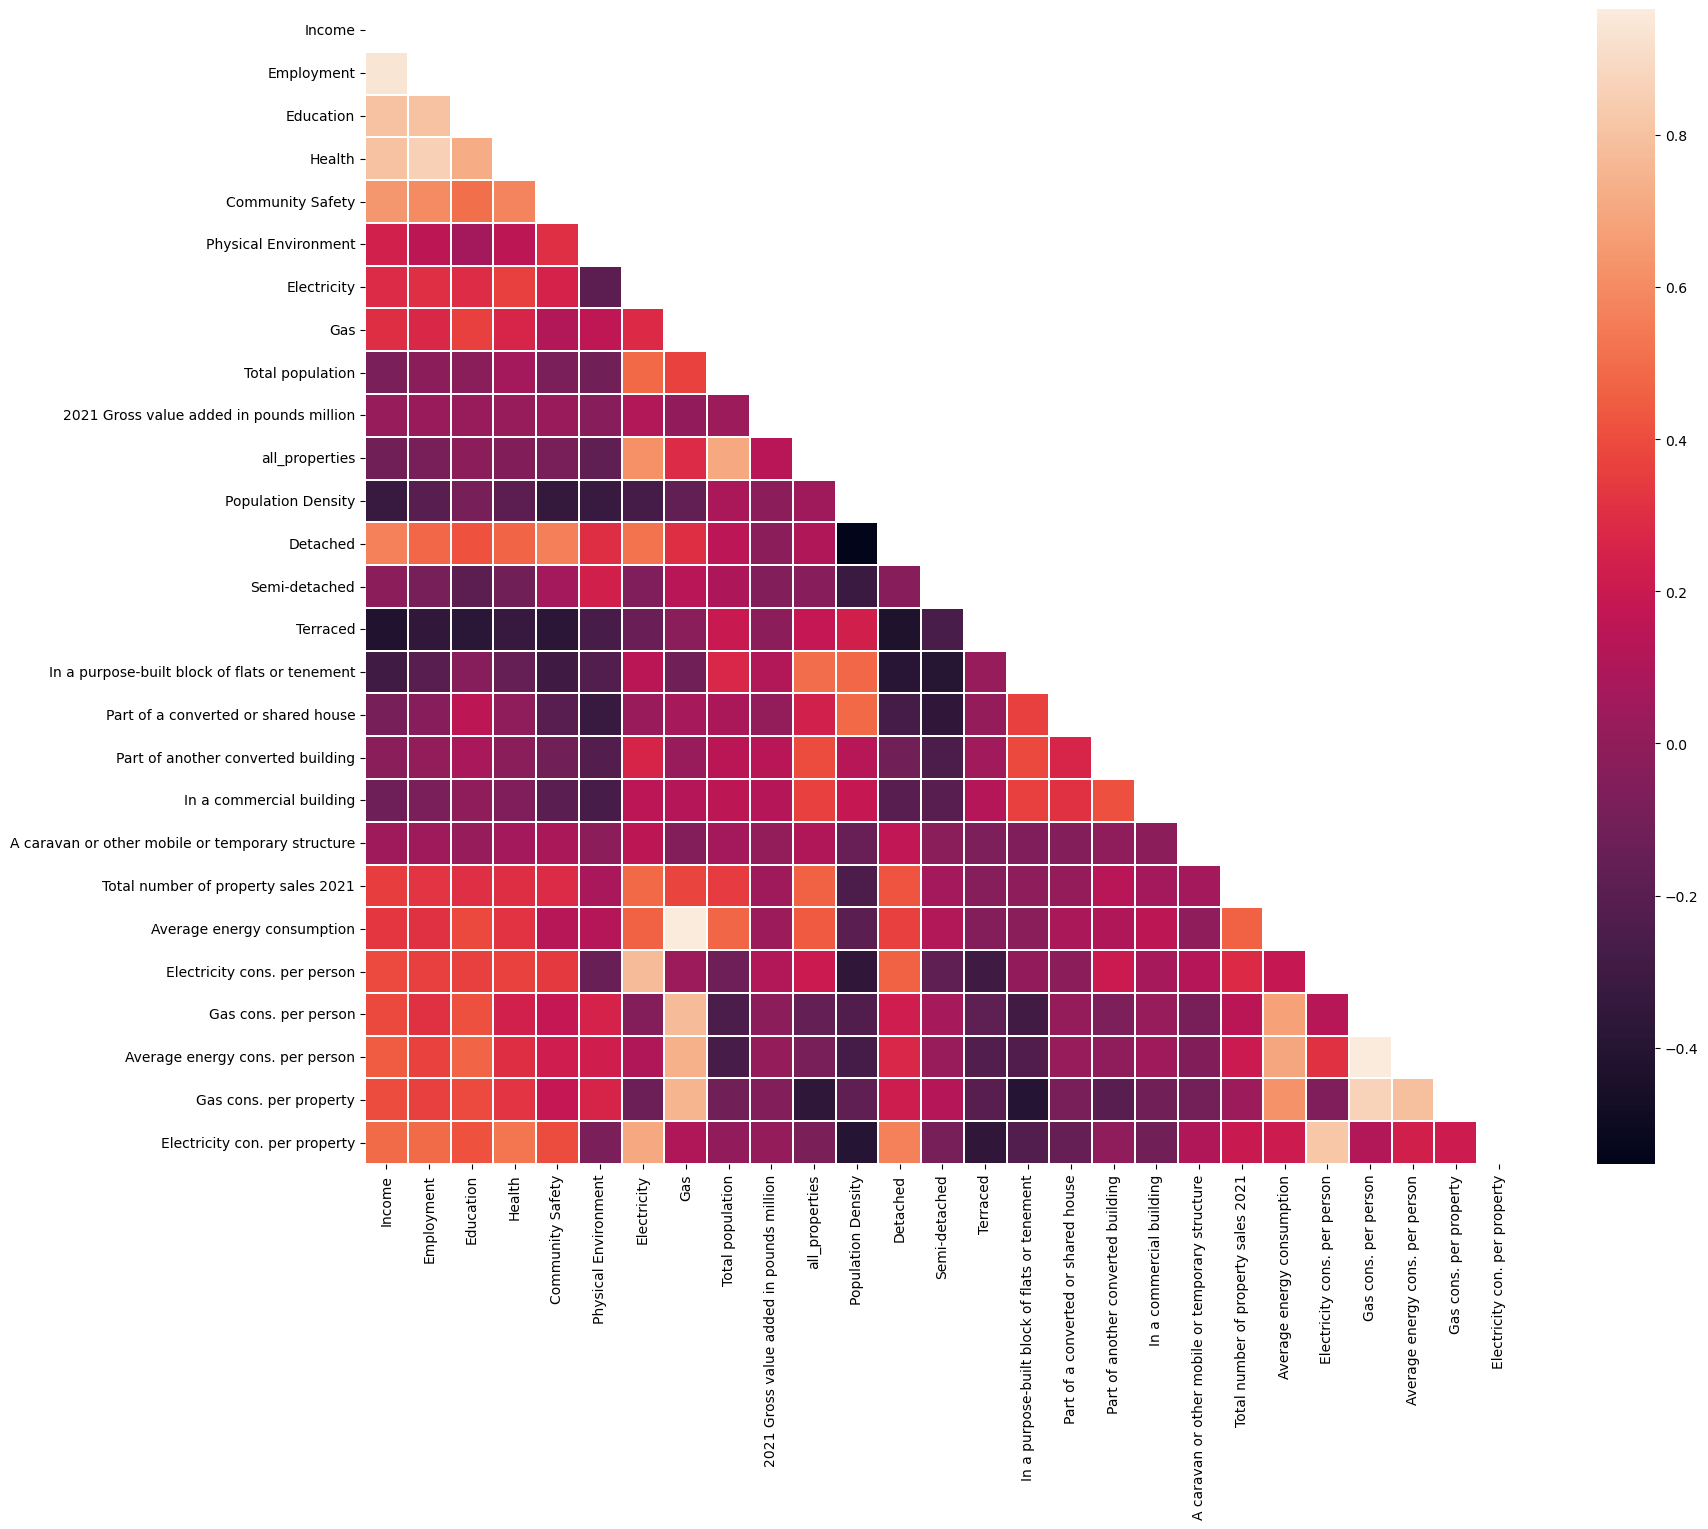

In [77]:
plt.figure(figsize=(20,15))
sns.heatmap(correlations, annot=True, mask=mask,fmt='.1f',square=True,
            linecolor='white',linewidths=0.2)
plt.show()




# Feature creation for X_test data

In [78]:
# X_test data
#creating features for X_test data
X_test = feature_creation(X_test).copy()

# FOR SHAP

In [79]:
#shap_processor = Pipeline([('impute',SimpleImputer(strategy='mean')),
#                 ('log', FunctionTransformer(np.log)),
#                 ('scaler',StandardScaler())
#                        ])

In [80]:
#log features
log_preprocessor = Pipeline([('impute', SimpleImputer(strategy='mean')),
                             ('log', FunctionTransformer(np.log)),
                             ('scaler',StandardScaler())
                              ])

In [81]:
#non log features
sqrt_preprocessor = Pipeline([('impute', SimpleImputer(strategy='mean')),
                              ('sqrt', FunctionTransformer(np.sqrt)),
                              ('scaler',StandardScaler())
                              ])

In [82]:
sqrt_features = ['Detached', 'Semi-detached',
                   'Terraced', 'In a purpose-built block of flats or tenement',
                   'Part of a converted or shared house',
                   'Part of another converted building', 'In a commercial building',
                   'A caravan or other mobile or temporary structure']

In [83]:
log_features = X_train.drop(['Detached', 'Semi-detached',
                           'Terraced', 'In a purpose-built block of flats or tenement',
                           'Part of a converted or shared house',
                           'Part of another converted building', 'In a commercial building',
                           'A caravan or other mobile or temporary structure'],axis=1).columns

In [84]:
col_tfr = ColumnTransformer([('log',log_preprocessor, log_features),
                  ('sqrt', sqrt_preprocessor, sqrt_features)])

In [85]:
shap_processor = ColumnTransformer([('log',log_preprocessor, log_features),
                  ('sqrt', sqrt_preprocessor, sqrt_features)])

In [86]:
shap_x_train = shap_processor.fit_transform(X_train)
shap_x_train = pd.DataFrame(shap_x_train, columns=X_train.columns)

In [87]:
shap_x_test = shap_processor.transform(X_test)
shap_x_test = pd.DataFrame(shap_x_test, columns=X_test.columns)

# APPLYING ALGORITHMS

In [88]:
#linear_model = Pipeline([('impute',SimpleImputer(strategy='mean')),
#                 ('log', FunctionTransformer(np.log)),
#                 ('scaler',StandardScaler()),
#                ('linear',LinearRegression())
#                        ])

In [89]:
#pre_processor = ColumnTransformer([('numeric', pipe, columns)])

In [90]:
#to check scores
def train_metrics(best_model, X_train, y_train):
    y_train_pred = best_model.predict(X_train)
    print(f"Train R-Square: {r2_score(y_train, y_train_pred)*100}")
    print(f"Train RMSE: {root_mean_squared_error(y_train, y_train_pred)}")
    print(f"Train MAE: {mean_absolute_error(y_train, y_train_pred)}")
    
def test_metrics(best_model, X_test, y_test):
    y_test_pred = best_model.predict(X_test)
    print(f"Test R-Square:{r2_score(y_test, y_test_pred)*100}")
    print(f"Test RMSE: {root_mean_squared_error(y_test, y_test_pred)}")
    print(f"Test MAE: {mean_absolute_error(y_test, y_test_pred)}")


# linear model

In [91]:
linear_model = Pipeline([('coltfr', col_tfr),
                         ('linear',LinearRegression())])

In [92]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('coltfr',
                 ColumnTransformer(transformers=[('log',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('log',
                                                                   FunctionTransformer(func=<ufunc 'log'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Income', 'Employment', 'Education', 'Health', 'Community Safety',
       'Physical Environment', 'Electricity', 'Gas', 'Total population',
       '2021 Gross value added in pounds million',...
                                                                   SimpleImputer()),
                                                                  ('sqrt',
                                                                   FunctionTransformer(func=<ufunc 'sqrt'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Detached', 'Semi-detached',
                                                   'Terraced',
                                                   'In a purpose-built block '
                                                   'of flats or tenement',
                                                   'Part of a converted or '
                                                   'shared house',
                                                   'Part of another converted '
                                                   'building',
                                                   'In a commercial building',
                                                   'A caravan or other mobile '
                                                   'or temporary '
                                                   'structure'])])),
                ('linear', LinearRegression())])

In [93]:
train_metrics(linear_model, X_train, y_train)
print()
print('******************************************')
print()
test_metrics(linear_model, X_test, y_test)

Train R-Square: 58.541922819706784
Train RMSE: 141298.48746659778
Train MAE: 86574.80216006594

******************************************

Test R-Square:60.52207036477488
Test RMSE: 134182.06575076358
Test MAE: 83366.59095833768


# RandomForest

In [94]:
#random_model_basic = Pipeline([('impute',SimpleImputer(strategy='mean')),
#                             ('log', FunctionTransformer(np.log)),
#                             ('scaler',StandardScaler()),
#                            ('randombasic',RandomForestRegressor(random_state=4))
#                                    ])

In [95]:
random_model_basic = Pipeline([('coltfr', col_tfr),
                         ('randombasic',RandomForestRegressor(random_state=4))])

In [96]:
random_model_basic.fit(X_train, y_train)

Pipeline(steps=[('coltfr',
                 ColumnTransformer(transformers=[('log',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('log',
                                                                   FunctionTransformer(func=<ufunc 'log'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Income', 'Employment', 'Education', 'Health', 'Community Safety',
       'Physical Environment', 'Electricity', 'Gas', 'Total population',
       '2021 Gross value added in pounds million',...
                                                                   FunctionTransformer(func=<ufunc 'sqrt'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Detached', 'Semi-detached',
                                                   'Terraced',
                                                   'In a purpose-built block '
                                                   'of flats or tenement',
                                                   'Part of a converted or '
                                                   'shared house',
                                                   'Part of another converted '
                                                   'building',
                                                   'In a commercial building',
                                                   'A caravan or other mobile '
                                                   'or temporary '
                                                   'structure'])])),
                ('randombasic', RandomForestRegressor(random_state=4))])

In [97]:
train_metrics(random_model_basic, X_train, y_train)
print()
print('******************************************')
print()
test_metrics(random_model_basic, X_test, y_test)

Train R-Square: 96.92096933786596
Train RMSE: 38507.022790064824
Train MAE: 22425.668143272138

******************************************

Test R-Square:78.79087495319716
Test RMSE: 98350.97409124067
Test MAE: 58405.52557829057


# decision trees

In [98]:
#decision_model_basic = Pipeline([('impute',SimpleImputer(strategy='mean')),
#                             ('log', FunctionTransformer(np.log)),
#                             ('scaler',StandardScaler()),
#                            ('decision',DecisionTreeRegressor(random_state=7))
#                                    ])

In [99]:
decision_model_basic = Pipeline([('coltfr', col_tfr),
                         ('decision',DecisionTreeRegressor(random_state=7))])

In [100]:
decision_model_basic.fit(X_train, y_train)

Pipeline(steps=[('coltfr',
                 ColumnTransformer(transformers=[('log',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('log',
                                                                   FunctionTransformer(func=<ufunc 'log'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Income', 'Employment', 'Education', 'Health', 'Community Safety',
       'Physical Environment', 'Electricity', 'Gas', 'Total population',
       '2021 Gross value added in pounds million',...
                                                                   FunctionTransformer(func=<ufunc 'sqrt'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Detached', 'Semi-detached',
                                                   'Terraced',
                                                   'In a purpose-built block '
                                                   'of flats or tenement',
                                                   'Part of a converted or '
                                                   'shared house',
                                                   'Part of another converted '
                                                   'building',
                                                   'In a commercial building',
                                                   'A caravan or other mobile '
                                                   'or temporary '
                                                   'structure'])])),
                ('decision', DecisionTreeRegressor(random_state=7))])

In [101]:
train_metrics(decision_model_basic, X_train, y_train)
print()
print('******************************************')
print()
test_metrics(decision_model_basic, X_test, y_test)

Train R-Square: 100.0
Train RMSE: 0.0
Train MAE: 0.0

******************************************

Test R-Square:46.26021316956474
Test RMSE: 156554.3931195378
Test MAE: 85834.66738706079


# xgboost

In [102]:
#xgboost_basic = Pipeline([('impute',SimpleImputer(strategy='mean')),
#                             ('log', FunctionTransformer(np.log)),
#                             ('scaler',StandardScaler()),
#                            ('xgboost',XGBRFRegressor(random_state=11))
#                                    ])

In [103]:
xgboost_basic = Pipeline([('coltfr', col_tfr),
                         ('xgboost',XGBRFRegressor(random_state=11))])

In [104]:
xgboost_basic.fit(X_train, y_train)

Pipeline(steps=[('coltfr',
                 ColumnTransformer(transformers=[('log',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('log',
                                                                   FunctionTransformer(func=<ufunc 'log'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Income', 'Employment', 'Education', 'Health', 'Community Safety',
       'Physical Environment', 'Electricity', 'Gas', 'Total population',
       '2021 Gross value added in pounds million',...
                                grow_policy=None, importance_type=None,
                                interaction_constraints=None, max_bin=None,
                                max_cat_threshold=None, max_cat_to_onehot=None,
                                max_delta_step=None, max_depth=None,
                                max_leaves=None, min_child_weight=None,
                                missing=nan, monotone_constraints=None,
                                multi_strategy=None, n_estimators=None,
                                n_jobs=None, num_parallel_tree=None,
                                objective='reg:squarederror', random_state=11,
                                reg_alpha=None, ...))])

In [105]:
train_metrics(xgboost_basic, X_train, y_train)
print()
print('******************************************')
print()
test_metrics(xgboost_basic, X_test, y_test)

Train R-Square: 78.14574621873247
Train RMSE: 102589.03061505716
Train MAE: 70240.64955663201

******************************************

Test R-Square:72.00284937294015
Test RMSE: 112998.89750313351
Test MAE: 71605.60390777503


# Using GridSearch

# Random Forest

In [106]:
#random_grid = Pipeline([('impute',SimpleImputer(strategy='mean')),
#                             ('log', FunctionTransformer(np.log)),
#                             ('scaler',StandardScaler()),
#                            ('randomgrid',RandomForestRegressor(random_state=6))
#                                    ])

In [126]:
random_grid = Pipeline([('coltfr', col_tfr),
                         ('randomgrid',RandomForestRegressor(random_state=6))])

In [127]:
param_random = {'randomgrid__max_depth': [3,5,10,None], 
                 'randomgrid__max_leaf_nodes': [3,10,None]
                 }

search_random = GridSearchCV(estimator=random_grid, 
                          param_grid=param_random, 
                          cv=5, 
                          scoring='neg_root_mean_squared_error')

In [128]:
search_random.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('coltfr',
                                        ColumnTransformer(transformers=[('log',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer()),
                                                                                         ('log',
                                                                                          FunctionTransformer(func=<ufunc 'log'>)),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Income', 'Employment', 'Education', 'Health', 'Community Safety',
       'Physical Environment', 'Electricity', 'Gas', 'Total population',
       '2021 Gros...
                                                                          'converted '
                                                                          'or '
                                                                          'shared '
                                                                          'house',
                                                                          'Part '
                                                                          'of '
                                                                          'another '
                                                                          'converted '
                                                                          'building',
                                                                          'In '
                                                                          'a '
                                                                          'commercial '
                                                                          'building',
                                                                          'A '
                                                                          'caravan '
                                                                          'or '
                                                                          'other '
                                                                          'mobile '
                                                                          'or '
                                                                          'temporary '
                                                                          'structure'])])),
                                       ('randomgrid',
                                        RandomForestRegressor(random_state=6))]),
             param_grid={'randomgrid__max_depth': [3, 5, 10, None],
                         'randomgrid__max_leaf_nodes': [3, 10, None]},
             scoring='neg_root_mean_squared_error')

In [129]:
search_random.best_estimator_

Pipeline(steps=[('coltfr',
                 ColumnTransformer(transformers=[('log',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('log',
                                                                   FunctionTransformer(func=<ufunc 'log'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Income', 'Employment', 'Education', 'Health', 'Community Safety',
       'Physical Environment', 'Electricity', 'Gas', 'Total population',
       '2021 Gross value added in pounds million',...
                                                                   FunctionTransformer(func=<ufunc 'sqrt'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Detached', 'Semi-detached',
                                                   'Terraced',
                                                   'In a purpose-built block '
                                                   'of flats or tenement',
                                                   'Part of a converted or '
                                                   'shared house',
                                                   'Part of another converted '
                                                   'building',
                                                   'In a commercial building',
                                                   'A caravan or other mobile '
                                                   'or temporary '
                                                   'structure'])])),
                ('randomgrid', RandomForestRegressor(random_state=6))])

In [130]:
best_random = search_random.best_estimator_

In [131]:
train_metrics(best_random, X_train, y_train)
print()
print('******************************************')
print()
test_metrics(best_random, X_test, y_test)

Train R-Square: 96.87654056230528
Train RMSE: 38783.84569853561
Train MAE: 22409.79777492447

******************************************

Test R-Square:78.42763401303732
Test RMSE: 99189.60919622716
Test MAE: 58637.32473786949


# XGBOOST

In [113]:
pipe_xgboost = Pipeline([('coltfr', col_tfr),
                         ('xgboost',XGBRFRegressor(random_state=91))])

In [114]:
params_xg_boost = {'xgboost__n_estimators': [50,100, 200,300],
                  'xgboost__max_depth': [3,4,5,6,8,None],
                  #'xgboost__min_child_weight': [1, 3, 5],
                  #'xgboost__subsample': [0.8, 0.9, 1.0]#,
                  #'xgboost__learning_rate': [0.01, 0.05, 0.1], 
                  #'xgboost__gamma': [0, 0.1, 0.2]
                 }

search_xg_boost = GridSearchCV(estimator=pipe_xgboost,
                              param_grid=params_xg_boost, 
                              cv=5, 
                              scoring='neg_root_mean_squared_error')

In [115]:
search_xg_boost.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('coltfr',
                                        ColumnTransformer(transformers=[('log',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer()),
                                                                                         ('log',
                                                                                          FunctionTransformer(func=<ufunc 'log'>)),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Income', 'Employment', 'Education', 'Health', 'Community Safety',
       'Physical Environment', 'Electricity', 'Gas', 'Total population',
       '2021 Gros...
                                                       max_depth=None,
                                                       max_leaves=None,
                                                       min_child_weight=None,
                                                       missing=nan,
                                                       monotone_constraints=None,
                                                       multi_strategy=None,
                                                       n_estimators=None,
                                                       n_jobs=None,
                                                       num_parallel_tree=None,
                                                       objective='reg:squarederror',
                                                       random_state=91,
                                                       reg_alpha=None, ...))]),
             param_grid={'xgboost__max_depth': [3, 4, 5, 6, 8, None],
                         'xgboost__n_estimators': [50, 100, 200, 300]},
             scoring='neg_root_mean_squared_error')

In [116]:
search_xg_boost.best_estimator_

Pipeline(steps=[('coltfr',
                 ColumnTransformer(transformers=[('log',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('log',
                                                                   FunctionTransformer(func=<ufunc 'log'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Income', 'Employment', 'Education', 'Health', 'Community Safety',
       'Physical Environment', 'Electricity', 'Gas', 'Total population',
       '2021 Gross value added in pounds million',...
                                grow_policy=None, importance_type=None,
                                interaction_constraints=None, max_bin=None,
                                max_cat_threshold=None, max_cat_to_onehot=None,
                                max_delta_step=None, max_depth=8,
                                max_leaves=None, min_child_weight=None,
                                missing=nan, monotone_constraints=None,
                                multi_strategy=None, n_estimators=200,
                                n_jobs=None, num_parallel_tree=None,
                                objective='reg:squarederror', random_state=91,
                                reg_alpha=None, ...))])

In [117]:
best_xgboost = search_xg_boost.best_estimator_

In [118]:
train_metrics(best_xgboost, X_train, y_train)
print()
print('******************************************')
print()
test_metrics(best_xgboost, X_test, y_test)

Train R-Square: 85.62130116436467
Train RMSE: 83213.29685724249
Train MAE: 59794.54581614571

******************************************

Test R-Square:76.00532889310614
Test RMSE: 104610.35840508548
Test MAE: 65255.52922824874


# SHAP

In [119]:
import shap

In [120]:
shap.initjs()

In [121]:
explainer = shap.Explainer(best_xgboost.named_steps.xgboost)

In [122]:
shap_values = explainer(shap_x_test)

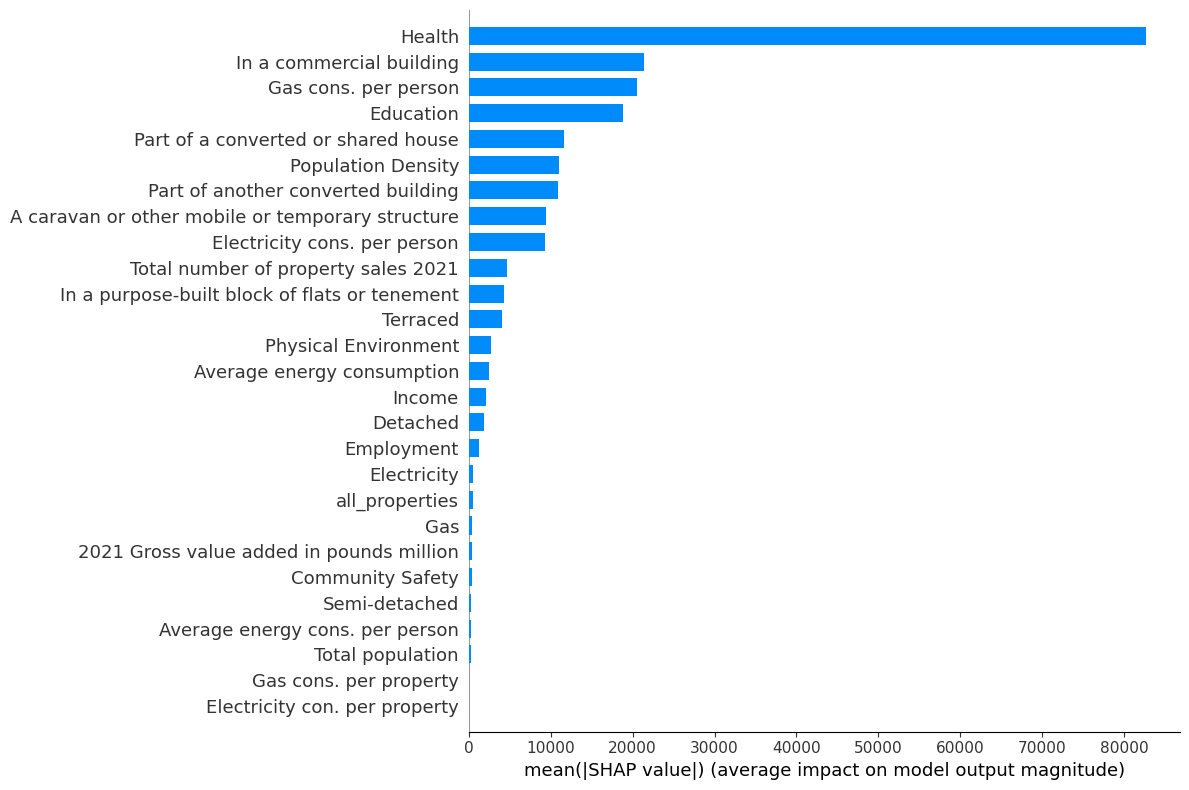

In [123]:
shap.summary_plot(shap_values, shap_x_test, plot_size=(12,8), plot_type='bar',max_display=35)

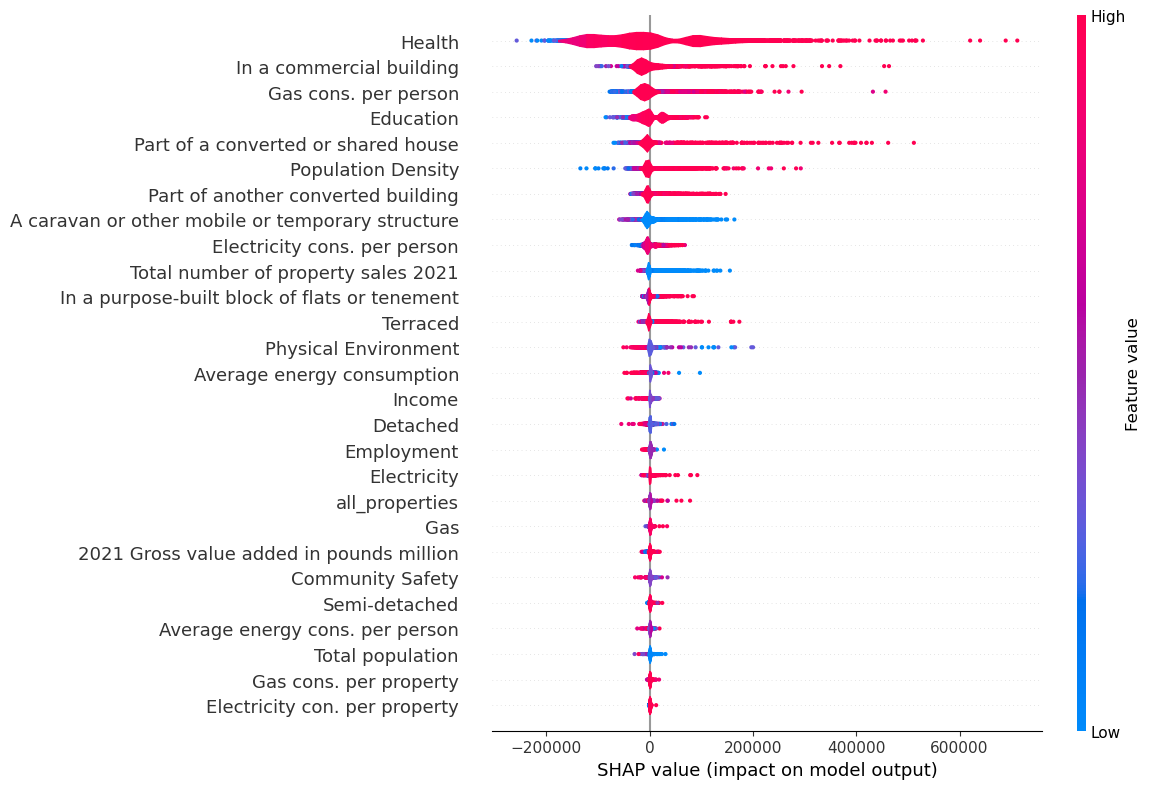

In [125]:
shap.summary_plot(shap_values, shap_x_test, plot_size=(12,8),max_display=35,plot_type='violin')